# **1. Perkenalan Dataset**


Dataset yang digunakan adalah **Wine Quality (Red Wine)** dari UCI Machine Learning Repository.

- **Sumber**: https://archive.ics.uci.edu/ml/datasets/wine+quality
- **Jumlah sampel**: 1.599 baris, 12 kolom
- **Fitur**: 11 atribut fisikokimia numerik *(fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol)*
- **Target**: `quality` (integer 3–8) → dikonversi ke label **0=Low (≤5)**, **1=Medium (6–7)**, **2=High (≥8)**
- **Task**: Multi-class classification (3 kelas)

# **2. Import Library**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os

# **3. Memuat Dataset**


In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# **4. Exploratory Data Analysis (EDA)**


In [3]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nJumlah baris duplikat: {df.duplicated().sum()}')

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Jumlah baris duplikat: 240


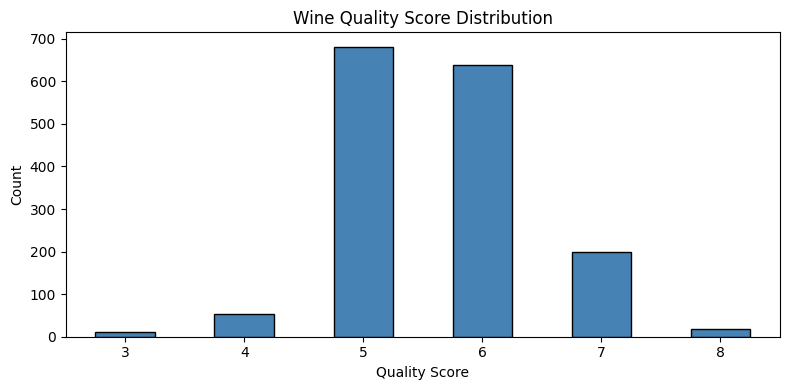

In [5]:
plt.figure(figsize=(8, 4))
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Wine Quality Score Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

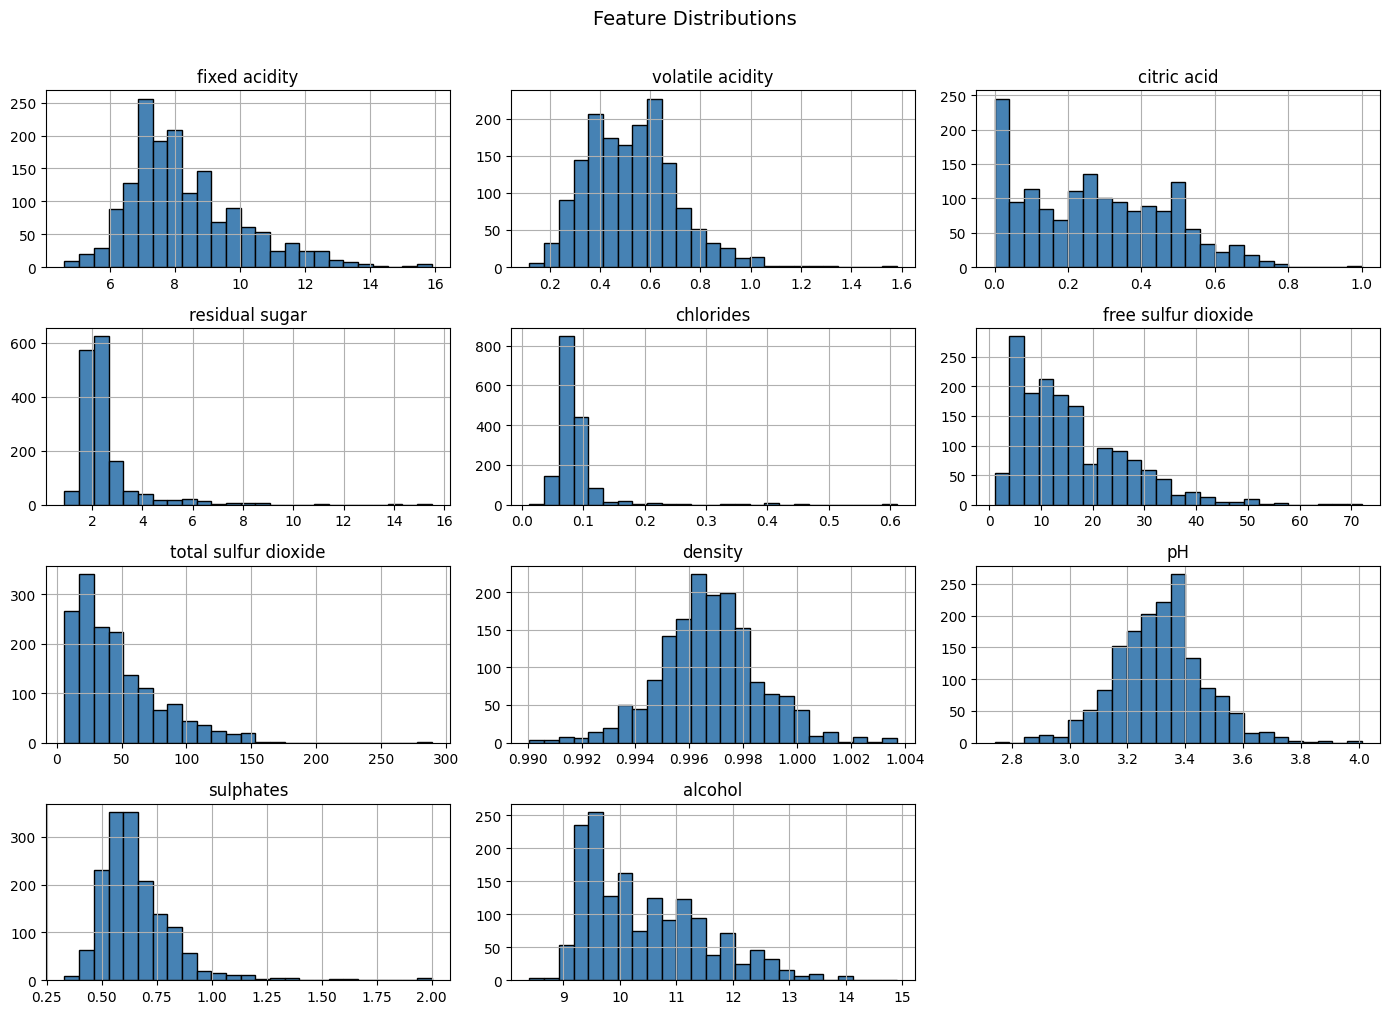

In [6]:
df.drop('quality', axis=1).hist(figsize=(14, 10), bins=25, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

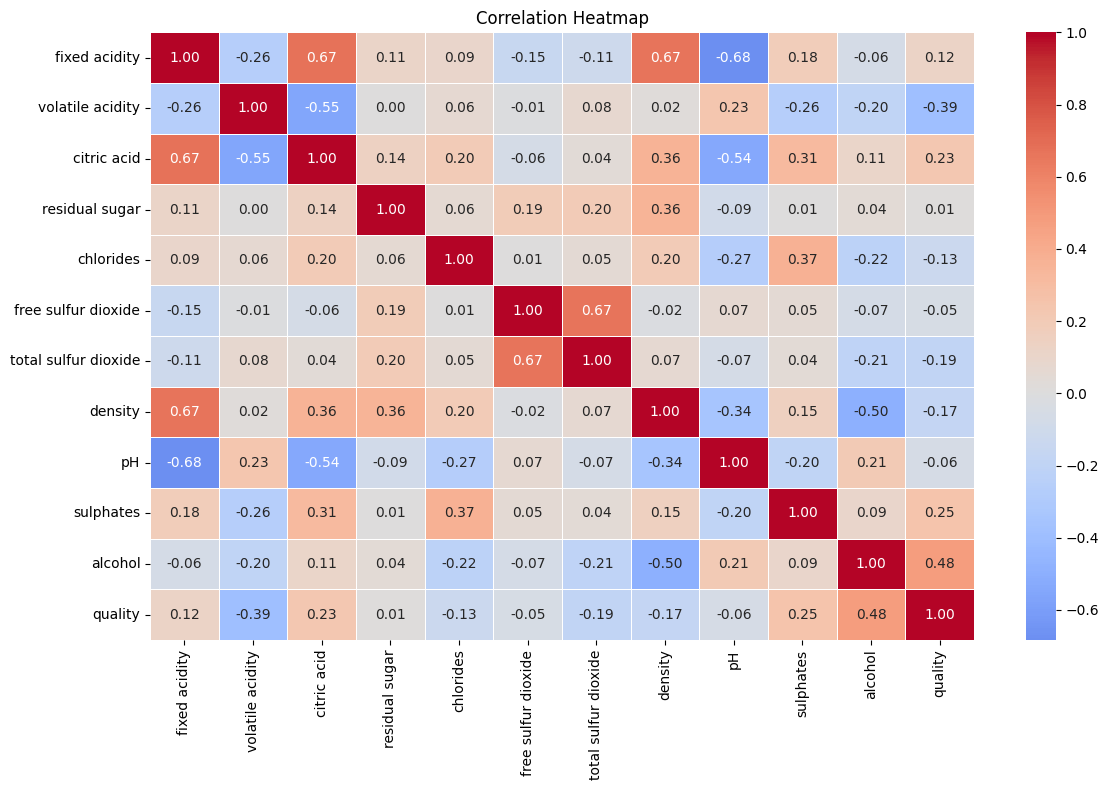

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Langkah-langkah preprocessing:
1. Menghapus baris duplikat
2. Mengonversi target `quality` → label 0 (Low), 1 (Medium), 2 (High)
3. Standarisasi fitur numerik dengan `StandardScaler`
4. Menyimpan dataset hasil preprocessing ke CSV

In [8]:
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape setelah menghapus duplikat: {df.shape}')

Shape setelah menghapus duplikat: (1359, 12)


In [9]:
df['quality_label'] = df['quality'].apply(lambda q: 0 if q <= 5 else (1 if q <= 7 else 2))
df = df.drop('quality', axis=1)

label_map = {0: 'Low (<=5)', 1: 'Medium (6-7)', 2: 'High (>=8)'}
print('Label distribution:')
print(df['quality_label'].map(label_map).value_counts())

Label distribution:
quality_label
Medium (6-7)    702
Low (<=5)       640
High (>=8)       17
Name: count, dtype: int64


In [10]:
X = df.drop('quality_label', axis=1)
y = df['quality_label']

X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
df_processed = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

print(f'Processed shape: {df_processed.shape}')
df_processed.head()

Processed shape: (1359, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_label
0,-0.524431,0.932000,-1.393258,-0.461157,-0.245623,-0.468554,-0.384050,0.584003,1.291872,-0.578561,-0.954374,0
1,-0.294063,1.915800,-1.393258,0.056665,0.200094,0.872003,0.604073,0.048737,-0.708395,0.124822,-0.584575,0
2,-0.294063,1.259934,-1.188617,-0.165259,0.078535,-0.085537,0.214813,0.155790,-0.321247,-0.051024,-0.584575,0
3,1.664067,-1.363534,1.471711,-0.461157,-0.265883,0.105971,0.394471,0.691057,-0.966495,-0.461331,-0.584575,1
4,-0.524431,0.713378,-1.393258,-0.535132,-0.265883,-0.277045,-0.204391,0.584003,1.291872,-0.578561,-0.954374,0


In [11]:
os.makedirs('winequality_preprocessing', exist_ok=True)
df_processed.to_csv('winequality_preprocessing/train.csv', index=False)
print('Saved to winequality_preprocessing/train.csv')

Saved to winequality_preprocessing/train.csv
